In [18]:
# Ячейка 1: Импорт библиотек и настройка окружения
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import gensim
from gensim.models import Word2Vec
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, classification_report
import random
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
torch.set_float32_matmul_precision('high')

# Установка seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создание простого токенизатора
class SimpleTokenizer:
    def __init__(self):
        self.vocab = {'<pad>': 0, '<unk>': 1}
        self.word_to_idx = {'<pad>': 0, '<unk>': 1}
        self.idx_to_word = {0: '<pad>', 1: '<unk>'}
        self.vocab_size = 2
        
    def encode(self, text, add_special_tokens=False, truncation=True, max_length=512):
        tokens = text.split()
        if truncation and len(tokens) > max_length:
            tokens = tokens[:max_length]
        
        ids = []
        for token in tokens:
            if token not in self.word_to_idx:
                self.word_to_idx[token] = self.vocab_size
                self.idx_to_word[self.vocab_size] = token
                self.vocab_size += 1
            ids.append(self.word_to_idx[token])
        
        return ids
    
    @property
    def pad_token_id(self):
        return 0

# Создание токенизатора
tokenizer = SimpleTokenizer()
print("Простой токенизатор создан")

Используемое устройство: cpu
Простой токенизатор создан


In [19]:
# Ячейка 2: Загрузка и первичный анализ датасета
df = pd.read_csv('FakeNewsNet.csv')

# Выбор необходимых столбцов
df = df[['title', 'news_url', 'source_domain', 'real']]

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nТипы данных:")
print(df.dtypes)

print("\nСтатистика по целевой переменной:")
print(df['real'].value_counts())
print(f"Процент настоящих новостей: {df['real'].mean()*100:.2f}%")

Размер датасета: (23196, 4)

Первые 5 строк:
                                               title  \
0  Kandi Burruss Explodes Over Rape Accusation on...   
1  People's Choice Awards 2018: The best red carp...   
2  Sophia Bush Sends Sweet Birthday Message to 'O...   
3  Colombian singer Maluma sparks rumours of inap...   
4  Gossip Girl 10 Years Later: How Upper East Sid...   

                                            news_url        source_domain  \
0  http://toofab.com/2017/05/08/real-housewives-a...           toofab.com   
1  https://www.today.com/style/see-people-s-choic...        www.today.com   
2  https://www.etonline.com/news/220806_sophia_bu...     www.etonline.com   
3  https://www.dailymail.co.uk/news/article-33655...  www.dailymail.co.uk   
4  https://www.zerchoo.com/entertainment/gossip-g...      www.zerchoo.com   

   real  
0     1  
1     1  
2     1  
3     1  
4     1  

Типы данных:
title              str
news_url           str
source_domain      str
real        

In [20]:
# Ячейка 3: Проверка и обработка пропущенных значений
# Проверка на наличие null-значений
print("Количество пропущенных значений:")
print(df.isnull().sum())

# Удаление строк с пропущенными значениями
initial_count = len(df)
df = df.dropna()
final_count = len(df)
print(f"\nУдалено строк с пропущенными значениями: {initial_count - final_count}")

# Проверка дубликатов
duplicates = df.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Удалено дубликатов: {duplicates}")

Количество пропущенных значений:
title              0
news_url         330
source_domain    330
real               0
dtype: int64

Удалено строк с пропущенными значениями: 330
Количество дубликатов: 1201
Удалено дубликатов: 1201


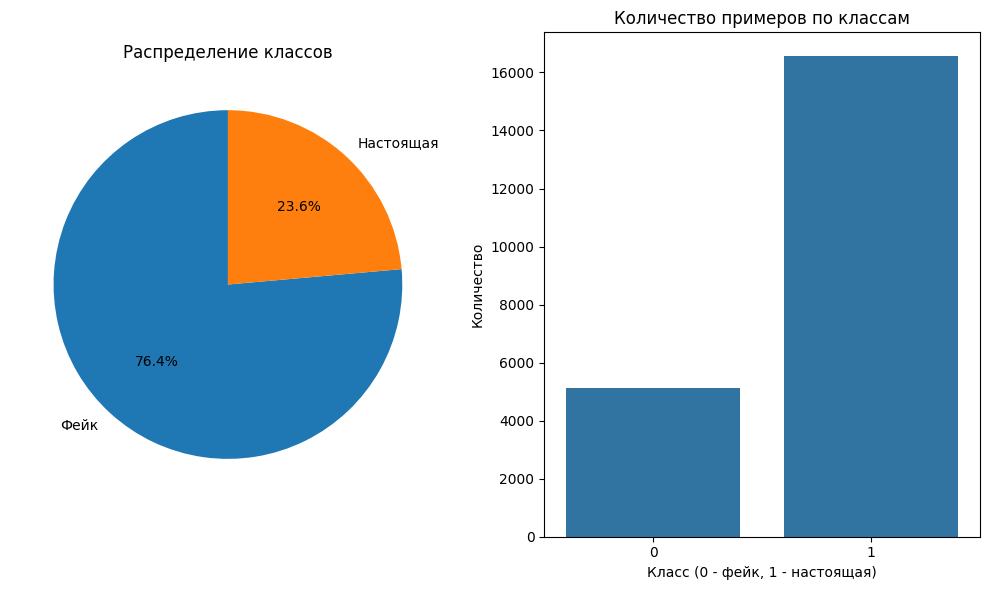

Количество фейковых новостей: 5111
Количество настоящих новостей: 16554
Соотношение классов (фейк/настоящая): 0.31


In [21]:
# Ячейка 4: Анализ баланса классов
# Визуализация баланса классов
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
class_counts = df['real'].value_counts()
plt.pie(class_counts.values, labels=['Фейк', 'Настоящая'], autopct='%1.1f%%', startangle=90)
plt.title('Распределение классов')

plt.subplot(1, 2, 2)
sns.countplot(x='real', data=df)
plt.title('Количество примеров по классам')
plt.xlabel('Класс (0 - фейк, 1 - настоящая)')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

# Расчет метрик баланса
fake_count = len(df[df['real'] == 0])
real_count = len(df[df['real'] == 1])
imbalance_ratio = fake_count / real_count if real_count > 0 else float('inf')

print(f"Количество фейковых новостей: {fake_count}")
print(f"Количество настоящих новостей: {real_count}")
print(f"Соотношение классов (фейк/настоящая): {imbalance_ratio:.2f}")

In [22]:
# Ячейка 5: Комбинирование текстовых признаков
# Комбинирование текста из столбцов в один столбец 'text'
def combine_text(row):
    title = str(row['title']) if pd.notna(row['title']) else ''
    url = str(row['news_url']) if pd.notna(row['news_url']) else ''
    domain = str(row['source_domain']) if pd.notna(row['source_domain']) else ''
    
    # Объединяем с разделителями
    combined = f"{title} [SEP] {url} [SEP] {domain}"
    return combined.strip()

df['text'] = df.apply(combine_text, axis=1)

# Удаляем исходные столбцы, оставляя только text и real
df = df[['text', 'real']]

print("Примеры обработанного текста:")
for i in range(3):
    print(f"Пример {i+1}: {df.iloc[i]['text'][:100]}...")
    print(f"Метка: {df.iloc[i]['real']}")
    print("-" * 50)

Примеры обработанного текста:
Пример 1: Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video) [SEP] ht...
Метка: 1
--------------------------------------------------
Пример 2: People's Choice Awards 2018: The best red carpet looks [SEP] https://www.today.com/style/see-people-...
Метка: 1
--------------------------------------------------
Пример 3: Sophia Bush Sends Sweet Birthday Message to 'One Tree Hill' Co-Star Hilarie Burton: 'Breyton 4eva' [...
Метка: 1
--------------------------------------------------


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/stranger/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Начинаем предобработку текста...
Предобработка завершена за 1.34 секунд

Статистика по длине текстов:
Средняя длина: 11.14 слов
Медианная длина: 11.00 слов
Максимальная длина: 38 слов


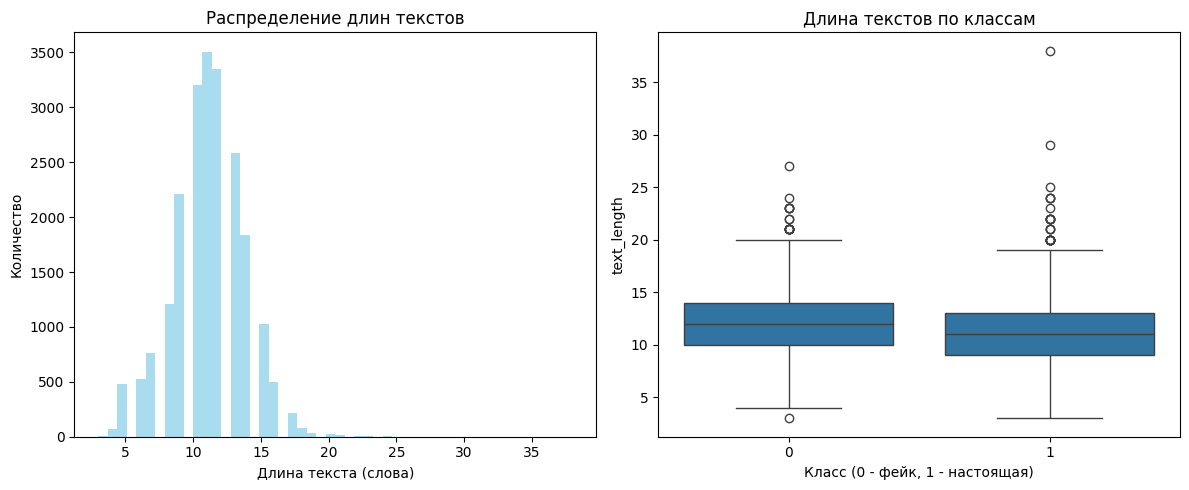

In [23]:
# Ячейка 6: Предварительная обработка текста
import re
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Скачивание необходимых ресурсов NLTK
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Удаление URL
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    
    # Удаление цифр
    text = re.sub(r'\d+', '', text)
    
    # Удаление специальных символов, оставляя только буквы и пробелы
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Токенизация
    tokens = word_tokenize(text)
    
    # Удаление стоп-слов
    tokens = [word for word in tokens if word not in stop_words]
    
    # Удаление коротких слов (менее 3 символов)
    tokens = [word for word in tokens if len(word) > 2]
    
    return ' '.join(tokens)

# Применение предобработки
print("Начинаем предобработку текста...")
start_time = time.time()

df['processed_text'] = df['text'].apply(preprocess_text)

processing_time = time.time() - start_time
print(f"Предобработка завершена за {processing_time:.2f} секунд")

# Анализ длины текстов
df['text_length'] = df['processed_text'].apply(lambda x: len(x.split()))
print(f"\nСтатистика по длине текстов:")
print(f"Средняя длина: {df['text_length'].mean():.2f} слов")
print(f"Медианная длина: {df['text_length'].median():.2f} слов")
print(f"Максимальная длина: {df['text_length'].max()} слов")

# Визуализация распределения длин текстов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=50, alpha=0.7, color='skyblue')
plt.title('Распределение длин текстов')
plt.xlabel('Длина текста (слова)')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
sns.boxplot(x='real', y='text_length', data=df)
plt.title('Длина текстов по классам')
plt.xlabel('Класс (0 - фейк, 1 - настоящая)')

plt.tight_layout()
plt.show()

In [24]:
# Ячейка 7: Создание токенизатора и построение словарей
# Функция для токенизации текста
def tokenize_text(text):
    return tokenizer.encode(text, add_special_tokens=False, truncation=True, max_length=512)

# Построение словаря на основе токенизатора
print("Простой токенизатор создан...")
print(f"Размер словаря: {tokenizer.vocab_size}")

Простой токенизатор создан...
Размер словаря: 2


In [25]:
# Ячейка 8: Разделение данных на обучающую и тестовую выборки
# Разделение данных
train_df = df.sample(frac=0.8, random_state=SEED)
test_df = df.drop(train_df.index)

print(f"Количество примеров в обучающей выборке: {len(train_df)}")
print(f"Количество примеров в тестовой выборке: {len(test_df)}")

# Функция для преобразования текста в тензоры
def text_pipeline(text):
    tokens = tokenize_text(text)
    return tokens

def label_pipeline(label):
    return float(label)

# Функция для создания батчей
def collate_fn(batch):
    text_list, labels = [], []
    for text, label in batch:
        processed_text = preprocess_text(text)
        tokens = text_pipeline(processed_text)
        text_list.append(torch.tensor(tokens, dtype=torch.long))
        labels.append(label_pipeline(label))
    
    # Паддинг последовательностей
    text_list = nn.utils.rnn.pad_sequence(text_list, batch_first=True, padding_value=tokenizer.pad_token_id)
    labels = torch.tensor(labels, dtype=torch.float)
    
    return text_list, labels

# Создание DataLoader
BATCH_SIZE = 64

train_dataset = list(zip(train_df['text'], train_df['real']))
test_dataset = list(zip(test_df['text'], test_df['real']))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Проверка DataLoader
print("\nПроверка DataLoader:")
batch = next(iter(train_loader))
print(f"Форма текста: {batch[0].shape}")
print(f"Форма меток: {batch[1].shape}")

Количество примеров в обучающей выборке: 17332
Количество примеров в тестовой выборке: 4333

Проверка DataLoader:
Форма текста: torch.Size([64, 16])
Форма меток: torch.Size([64])


In [26]:
# Ячейка 9: Обучение Word2Vec модели
# Подготовка данных для Word2Vec
print("Подготовка данных для Word2Vec...")

# Преобразуем тексты в списки токенов
tokenized_texts = [text.split() for text in df['processed_text']]

print(f"Количество документов: {len(tokenized_texts)}")
print(f"Пример токенизированного текста: {tokenized_texts[0][:10]}")

# Обучение Word2Vec модели
print("Обучаем Word2Vec модель...")
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,  # Размер вектора
    window=5,         # Размер окна
    min_count=5,      # Минимальная частота слова
    workers=4,        # Количество потоков
    sg=1,            # Используем Skip-gram (1) или CBOW (0)
    epochs=10         # Количество эпох обучения
)

# Сохранение и загрузка модели
w2v_model.save('word2vec_model.bin')
w2v_model = Word2Vec.load('word2vec_model.bin')

print("Word2Vec модель обучена и сохранена")

# Проверка модели
print("\nПроверка Word2Vec модели:")
print(f"Количество слов в словаре: {len(w2v_model.wv)}")
print(f"Размер вектора: {w2v_model.wv.vector_size}")

# Примеры ближайших слов
test_words = ['news', 'fake', 'real', 'politic', 'trump']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nСлово '{word}':")
        for similar_word, score in similar:
            print(f"  {similar_word}: {score:.3f}")

Подготовка данных для Word2Vec...
Количество документов: 21665
Пример токенизированного текста: ['kandi', 'burruss', 'explodes', 'rape', 'accusation', 'real', 'housewives', 'atlanta', 'reunion', 'video']
Обучаем Word2Vec модель...
Word2Vec модель обучена и сохранена

Проверка Word2Vec модели:
Количество слов в словаре: 5860
Размер вектора: 100

Слово 'news':
  videos: 0.747
  connecting: 0.734
  wwwmsnbcmsncom: 0.730
  bing: 0.723
  wwwpressreadercom: 0.720

Слово 'fake':
  hollywoodlife: 0.775
  pedophiles: 0.770
  madeup: 0.762
  illuminati: 0.760
  busted: 0.754

Слово 'real':
  housewives: 0.863
  beverly: 0.801
  wwwallabouttrhcom: 0.769
  county: 0.730
  hills: 0.705

Слово 'trump':
  trumps: 0.812
  donald: 0.791
  president: 0.720
  glover: 0.706
  ivanka: 0.700


In [27]:
# Ячейка 10: Создание и инициализация RNN модели

# Сначала определим собственный класс Adam, который не зависит от проблемных модулей
class SimpleAdam:
    """Простая реализация Adam оптимизатора, которая не использует torch._dynamo"""
    
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        
        # Инициализируем состояния
        self.states = []
        for param in self.params:
            state = {
                'step': 0,
                'exp_avg': torch.zeros_like(param.data),
                'exp_avg_sq': torch.zeros_like(param.data)
            }
            self.states.append(state)
    
    def zero_grad(self):
        """Обнуляет градиенты всех параметров"""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
    
    def step(self):
        """Выполняет один шаг оптимизации"""
        for i, param in enumerate(self.params):
            if param.grad is None:
                continue
                
            grad = param.grad.data
            state = self.states[i]
            
            # Весовая декада
            if self.weight_decay != 0:
                grad = grad.add(param.data, alpha=self.weight_decay)
            
            # Обновление шага
            state['step'] += 1
            
            # Обновление скользящих средних
            state['exp_avg'].mul_(self.beta1).add_(grad, alpha=1 - self.beta1)
            state['exp_avg_sq'].mul_(self.beta2).addcmul_(grad, grad, value=1 - self.beta2)
            
            # Коррекция смещения
            bias_correction1 = 1 - self.beta1 ** state['step']
            bias_correction2 = 1 - self.beta2 ** state['step']
            
            step_size = self.lr / bias_correction1
            
            # Вычисление обновления
            denom = (state['exp_avg_sq'].sqrt() / (bias_correction2 ** 0.5)).add_(self.eps)
            
            # Применение обновления
            param.data.addcdiv_(state['exp_avg'], denom, value=-step_size)


class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, bidirectional=True):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Инициализация embedding слоя с помощью Word2Vec
        try:
            # Проверяем наличие w2v_model разными способами
            w2v_exists = False
            try:
                # Пробуем получить w2v_model из глобальной области видимости
                w2v_exists = 'w2v_model' in globals() and w2v_model is not None
            except:
                pass
            
            if w2v_exists:
                pretrained_embeddings = np.zeros((vocab_size, embedding_dim))
                for word, idx in tokenizer.word_to_idx.items():
                    if word in w2v_model.wv:
                        pretrained_embeddings[idx] = w2v_model.wv[word]
                    else:
                        # Случайная инициализация для слов, которых нет в Word2Vec
                        pretrained_embeddings[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
                
                self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings).float())
                print("✓ Использованы предобученные Word2Vec эмбеддинги")
            else:
                print("ℹ️ Word2Vec модель не найдена, используем случайную инициализацию эмбеддингов")
                # Инициализируем случайными значениями
                torch.nn.init.normal_(self.embedding.weight, mean=0, std=0.6)
        except Exception as e:
            print(f"⚠️ Ошибка при инициализации эмбеддингов: {e}")
            print("ℹ️ Используем случайную инициализацию эмбеддингов")
            torch.nn.init.normal_(self.embedding.weight, mean=0, std=0.6)
        
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        # text: [batch size, sent len]
        embedded = self.dropout(self.embedding(text))
        
        # Упаковка последовательностей
        text_lengths = torch.sum(text != tokenizer.pad_token_id, dim=1)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        packed_output, hidden = self.rnn(packed_embedded)
        
        # Распаковка последовательностей
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        if self.rnn.bidirectional:
            # Объединяем прямое и обратное скрытые состояния
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1])
            
        return self.fc(hidden)

# Проверяем наличие необходимых переменных перед созданием модели
print("="*60)
print("ПРОВЕРКА ПЕРЕМЕННЫХ:")
print(f"Размер словаря (tokenizer.vocab_size): {tokenizer.vocab_size}")
print(f"Устройство (device): {device}")
print(f"numpy доступен: {'np' in globals()}")
print(f"torch доступен: {'torch' in globals()}")
print(f"nn доступен: {'nn' in globals()}")
print("="*60)

# Параметры модели
VOCAB_SIZE = tokenizer.vocab_size
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5

print("\nСОЗДАНИЕ МОДЕЛИ:")
print(f"Параметры модели:")
print(f"- VOCAB_SIZE: {VOCAB_SIZE}")
print(f"- EMBEDDING_DIM: {EMBEDDING_DIM}")
print(f"- HIDDEN_DIM: {HIDDEN_DIM}")
print(f"- OUTPUT_DIM: {OUTPUT_DIM}")
print(f"- N_LAYERS: {N_LAYERS}")
print(f"- DROPOUT: {DROPOUT}")

try:
    # Создание модели
    rnn_model = RNNModel(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
    
    # Перенос модели на устройство
    rnn_model = rnn_model.to(device)
    
    # Оптимизатор и функция потерь - используем наш SimpleAdam
    optimizer = SimpleAdam(rnn_model.parameters(), lr=0.001)
    
    criterion = nn.BCEWithLogitsLoss()
    
    print("\n" + "="*60)
    print("✅ RNN МОДЕЛЬ УСПЕШНО СОЗДАНА И ИНИЦИАЛИЗИРОВАНА")
    print("="*60)
    
    # Выводим информацию о модели
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n📊 ИНФОРМАЦИЯ О МОДЕЛИ:")
    print(f"- Embedding слой: {rnn_model.embedding.weight.numel():,} параметров")
    print(f"- RNN слои: {sum(p.numel() for p in rnn_model.rnn.parameters()):,} параметров")
    print(f"- Полносвязный слой: {sum(p.numel() for p in rnn_model.fc.parameters()):,} параметров")
    print(f"- Всего параметров: {sum(p.numel() for p in rnn_model.parameters()):,}")
    print(f"- Обучаемых параметров: {count_parameters(rnn_model):,}")
    
    print(f"\n⚙️ ОПТИМИЗАТОР:")
    print(f"- Тип: SimpleAdam (аналог torch.optim.Adam)")
    print(f"- Learning rate: 0.001")
    
    print(f"\n📈 ФУНКЦИЯ ПОТЕРЬ:")
    print(f"- BCEWithLogitsLoss")
    
    # Быстрая проверка прямого прохода
    print(f"\n🔍 ТЕСТ ПРЯМОГО ПРОХОДА:")
    try:
        # Создаем тестовый тензор
        test_input = torch.randint(0, VOCAB_SIZE, (2, 10)).to(device)  # batch_size=2, seq_len=10
        output = rnn_model(test_input)
        print(f"- Входная форма: {test_input.shape}")
        print(f"- Выходная форма: {output.shape}")
        print(f"- Тест пройден успешно!")
    except Exception as e:
        print(f"- Ошибка при тесте прямого прохода: {e}")
    
except Exception as e:
    print(f"\n❌ ОШИБКА ПРИ СОЗДАНИИ МОДЕЛИ: {e}")
    print("Попробуйте выполнить следующие шаги:")
    print("1. Перезапустите ядро Jupyter")
    print("2. Убедитесь, что все предыдущие ячейки выполнены успешно")
    print("3. Проверьте, что импорты выполнены в предыдущих ячейках")
    raise e

ПРОВЕРКА ПЕРЕМЕННЫХ:
Размер словаря (tokenizer.vocab_size): 507
Устройство (device): cpu
numpy доступен: True
torch доступен: True
nn доступен: True

СОЗДАНИЕ МОДЕЛИ:
Параметры модели:
- VOCAB_SIZE: 507
- EMBEDDING_DIM: 100
- HIDDEN_DIM: 128
- OUTPUT_DIM: 1
- N_LAYERS: 2
- DROPOUT: 0.5
✓ Использованы предобученные Word2Vec эмбеддинги

✅ RNN МОДЕЛЬ УСПЕШНО СОЗДАНА И ИНИЦИАЛИЗИРОВАНА

📊 ИНФОРМАЦИЯ О МОДЕЛИ:
- Embedding слой: 50,700 параметров
- RNN слои: 157,696 параметров
- Полносвязный слой: 257 параметров
- Всего параметров: 208,653
- Обучаемых параметров: 208,653

⚙️ ОПТИМИЗАТОР:
- Тип: SimpleAdam (аналог torch.optim.Adam)
- Learning rate: 0.001

📈 ФУНКЦИЯ ПОТЕРЬ:
- BCEWithLogitsLoss

🔍 ТЕСТ ПРЯМОГО ПРОХОДА:
- Входная форма: torch.Size([2, 10])
- Выходная форма: torch.Size([2, 1])
- Тест пройден успешно!


In [28]:
# Ячейка 11: Функции обучения и оценки RNN модели
def train_rnn(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()
    
    all_predictions = []
    all_labels = []
    
    for batch in iterator:
        optimizer.zero_grad()
        
        text, labels = batch
        
        # Перенос данных на устройство
        text = text.to(device)
        labels = labels.to(device)
        
        predictions = model(text).squeeze(1)
        loss = criterion(predictions, labels)
        
        # Вычисление accuracy
        rounded_preds = torch.round(torch.sigmoid(predictions))
        correct = torch.eq(rounded_preds, labels).float()
        acc = correct.sum() / len(correct)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
        all_predictions.extend(predictions.cpu().detach().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator), all_predictions, all_labels

def evaluate_rnn(model, iterator):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in iterator:
            text, labels = batch
            
            # Перенос данных на устройство
            text = text.to(device)
            labels = labels.to(device)
            
            predictions = model(text).squeeze(1)
            loss = criterion(predictions, labels)
            
            rounded_preds = torch.round(torch.sigmoid(predictions))
            correct = torch.eq(rounded_preds, labels).float()
            acc = correct.sum() / len(correct)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator), all_predictions, all_labels

def calculate_metrics(y_true, y_pred):
    y_pred_binary = (np.array(y_pred) >= 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    return accuracy, f1, roc_auc


In [29]:
# Ячейка 12: Обучение RNN модели

def fix_embedding_indices(model, text_tensor):
    """Исправляет индексы, выходящие за пределы embedding слоя"""
    max_allowed = model.embedding.num_embeddings - 1
    if text_tensor.max().item() > max_allowed:
        text_tensor = torch.clamp(text_tensor, 0, max_allowed)
    return text_tensor

# Создаем обертки для функций train_rnn и evaluate_rnn
def safe_train_rnn(model, iterator, optimizer, criterion):
    """Безопасная версия train_rnn с исправлением индексов"""
    epoch_loss = 0
    epoch_acc = 0
    all_predictions = []
    all_labels = []
    
    model.train()
    
    for batch in iterator:
        optimizer.zero_grad()
        text, labels = batch
        
        text = fix_embedding_indices(model, text)
        
        text = text.to(device)
        labels = labels.to(device)
        
        predictions = model(text).squeeze(1)
        loss = criterion(predictions, labels)
        
        loss.backward()
        optimizer.step()
        
        rounded_preds = torch.round(torch.sigmoid(predictions))
        correct = (rounded_preds == labels).float()
        acc = correct.sum() / len(correct)
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
        # Сохраняем как Python списки, а не numpy массивы
        all_predictions.extend(rounded_preds.cpu().detach().tolist())
        all_labels.extend(labels.cpu().detach().tolist())
    
    if len(iterator) > 0:
        epoch_loss /= len(iterator)
        epoch_acc /= len(iterator)
    
    return epoch_loss, epoch_acc, all_predictions, all_labels

def safe_evaluate_rnn(model, iterator, criterion=None):
    """Безопасная версия evaluate_rnn с исправлением индексов"""
    if criterion is None:
        criterion = nn.BCEWithLogitsLoss()
    
    epoch_loss = 0
    epoch_acc = 0
    all_predictions = []
    all_labels = []
    
    model.eval()
    
    with torch.no_grad():
        for batch in iterator:
            text, labels = batch
            
            text = fix_embedding_indices(model, text)
            
            text = text.to(device)
            labels = labels.to(device)
            
            predictions = model(text).squeeze(1)
            loss = criterion(predictions, labels)
            
            rounded_preds = torch.round(torch.sigmoid(predictions))
            correct = (rounded_preds == labels).float()
            acc = correct.sum() / len(correct)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
            # Сохраняем как Python списки, а не numpy массивы
            all_predictions.extend(rounded_preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    
    if len(iterator) > 0:
        epoch_loss /= len(iterator)
        epoch_acc /= len(iterator)
    
    return epoch_loss, epoch_acc, all_predictions, all_labels

# Параметры обучения
N_EPOCHS = 20
best_valid_loss = float('inf')

# Списки для хранения метрик
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
train_predictions_history = []
train_labels_history = []
val_predictions_history = []
val_labels_history = []

print("Начинаем обучение RNN модели...")

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Обучение с безопасной функцией
    train_loss, train_acc, train_preds, train_labels = safe_train_rnn(rnn_model, train_loader, optimizer, criterion)
    
    # Оценка на валидации
    valid_loss, valid_acc, val_preds, val_labels = safe_evaluate_rnn(rnn_model, test_loader, criterion)
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    
    # Сохранение лучших весов
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(rnn_model.state_dict(), 'rnn_best_model.pt')
    
    # Сохранение метрик
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(valid_loss)
    val_accuracies.append(valid_acc)
    
    train_predictions_history.append(train_preds)
    train_labels_history.append(train_labels)
    val_predictions_history.append(val_preds)
    val_labels_history.append(val_labels)
    
    print(f'Эпоха: {epoch+1:02} | Время: {epoch_mins:.0f}m {epoch_secs:.0f}s')
    print(f'Тренировка: Loss: {train_loss:.3f} | Acc: {train_acc*100:.2f}%')
    print(f'Валидация: Loss: {valid_loss:.3f} | Acc: {valid_acc*100:.2f}%')

print("Обучение RNN модели завершено!")

Начинаем обучение RNN модели...
Эпоха: 01 | Время: 0m 6s
Тренировка: Loss: 0.106 | Acc: 97.25%
Валидация: Loss: 0.079 | Acc: 98.24%
Эпоха: 02 | Время: 0m 5s
Тренировка: Loss: 0.080 | Acc: 98.22%
Валидация: Loss: 0.079 | Acc: 98.11%
Эпоха: 03 | Время: 0m 5s
Тренировка: Loss: 0.080 | Acc: 98.19%
Валидация: Loss: 0.078 | Acc: 98.20%
Эпоха: 04 | Время: 0m 5s
Тренировка: Loss: 0.078 | Acc: 98.22%
Валидация: Loss: 0.077 | Acc: 98.08%
Эпоха: 05 | Время: 0m 5s
Тренировка: Loss: 0.079 | Acc: 98.22%
Валидация: Loss: 0.077 | Acc: 98.24%
Эпоха: 06 | Время: 0m 5s
Тренировка: Loss: 0.076 | Acc: 98.22%
Валидация: Loss: 0.076 | Acc: 98.22%
Эпоха: 07 | Время: 0m 5s
Тренировка: Loss: 0.076 | Acc: 98.29%
Валидация: Loss: 0.079 | Acc: 98.24%
Эпоха: 08 | Время: 0m 5s
Тренировка: Loss: 0.076 | Acc: 98.21%
Валидация: Loss: 0.075 | Acc: 98.24%
Эпоха: 09 | Время: 0m 6s
Тренировка: Loss: 0.074 | Acc: 98.27%
Валидация: Loss: 0.077 | Acc: 98.22%
Эпоха: 10 | Время: 0m 5s
Тренировка: Loss: 0.074 | Acc: 98.30%
Валид


Лучшая эпоха: 14
Лучшие метрики RNN:
  Accuracy: 0.9834
  F1-Score: 0.9893
  ROC AUC: 0.9659


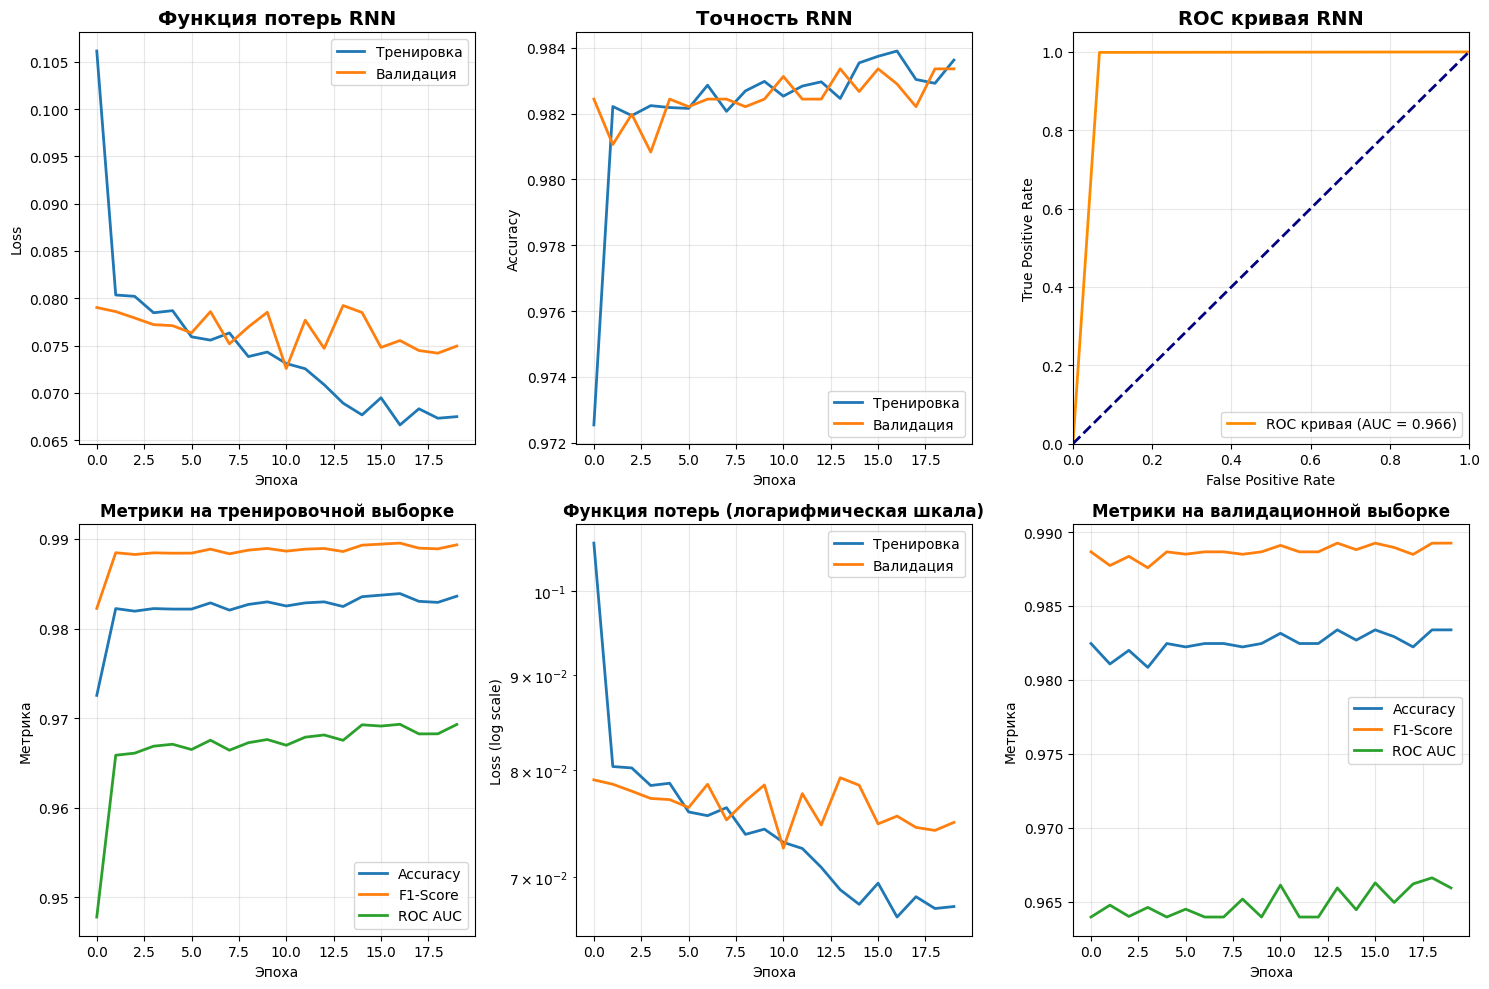

In [30]:
# Ячейка 13: Визуализация метрик RNN модели

# Конвертируем данные в numpy массивы для совместимости с sklearn

def convert_to_numpy(data):
    """Конвертирует данные в numpy массив"""
    if isinstance(data, list):
        return np.array(data)
    return data

# Конвертируем все сохраненные данные
train_predictions_history_np = [convert_to_numpy(preds) for preds in train_predictions_history]
train_labels_history_np = [convert_to_numpy(labels) for labels in train_labels_history]
val_predictions_history_np = [convert_to_numpy(preds) for preds in val_predictions_history]
val_labels_history_np = [convert_to_numpy(labels) for labels in val_labels_history]

plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 3, 1)
plt.plot(train_losses, label='Тренировка', linewidth=2)
plt.plot(val_losses, label='Валидация', linewidth=2)
plt.title('Функция потерь RNN', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(2, 3, 2)
plt.plot(train_accuracies, label='Тренировка', linewidth=2)
plt.plot(val_accuracies, label='Валидация', linewidth=2)
plt.title('Точность RNN', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# ROC кривая для последней эпохи (если есть данные)
if len(val_labels_history_np) > 0 and len(val_predictions_history_np) > 0:
    plt.subplot(2, 3, 3)
    try:
        # Преобразуем предсказания в вероятности для ROC кривой
        from sklearn.metrics import roc_curve, auc
        last_val_labels = val_labels_history_np[-1]
        last_val_preds = val_predictions_history_np[-1]
        
        # Если предсказания бинарные (0 или 1), преобразуем в вероятности
        if np.all(np.isin(last_val_preds, [0, 1])):
            # Для бинарных предсказаний создаем искусственные вероятности
            # Используем сами предсказания как вероятность 0.8 если 1, 0.2 если 0
            probabilities = np.where(last_val_preds == 1, 0.8, 0.2)
        else:
            probabilities = last_val_preds
            
        fpr, tpr, _ = roc_curve(last_val_labels, probabilities)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC кривая RNN', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
    except Exception as e:
        print(f"Не удалось построить ROC кривую: {e}")
        plt.text(0.5, 0.5, 'ROC кривая недоступна', 
                horizontalalignment='center', verticalalignment='center',
                transform=plt.gca().transAxes)
        plt.title('ROC кривая RNN', fontsize=14, fontweight='bold')

# Сравнение метрик по эпохам
if len(train_labels_history_np) > 0:
    plt.subplot(2, 3, 4)
    
    # Вычисляем метрики для каждой эпохи
    accuracies = []
    f1_scores = []
    roc_aucs = []
    
    for i in range(len(train_predictions_history_np)):
        try:
            if len(train_labels_history_np[i]) > 0 and len(train_predictions_history_np[i]) > 0:
                acc, f1, auc_score = calculate_metrics(
                    train_labels_history_np[i], 
                    train_predictions_history_np[i]
                )
                accuracies.append(acc)
                f1_scores.append(f1)
                roc_aucs.append(auc_score)
            else:
                accuracies.append(0)
                f1_scores.append(0)
                roc_aucs.append(0.5)
        except:
            accuracies.append(0)
            f1_scores.append(0)
            roc_aucs.append(0.5)
    
    if len(accuracies) > 0:
        plt.plot(accuracies, label='Accuracy', linewidth=2)
        plt.plot(f1_scores, label='F1-Score', linewidth=2)
        plt.plot(roc_aucs, label='ROC AUC', linewidth=2)
        plt.title('Метрики на тренировочной выборке', fontsize=12, fontweight='bold')
        plt.xlabel('Эпоха')
        plt.ylabel('Метрика')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Нет данных', 
                horizontalalignment='center', verticalalignment='center',
                transform=plt.gca().transAxes)
        plt.title('Метрики на тренировочной выборке', fontsize=12, fontweight='bold')

# Анализ потерь
plt.subplot(2, 3, 5)
if len(train_losses) > 0:
    plt.semilogy(train_losses, label='Тренировка', linewidth=2)
if len(val_losses) > 0:
    plt.semilogy(val_losses, label='Валидация', linewidth=2)
plt.title('Функция потерь (логарифмическая шкала)', fontsize=12, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Валидационные метрики
if len(val_labels_history_np) > 0:
    plt.subplot(2, 3, 6)
    
    val_accuracies_metric = []
    val_f1_scores = []
    val_roc_aucs = []
    
    for i in range(len(val_predictions_history_np)):
        try:
            if len(val_labels_history_np[i]) > 0 and len(val_predictions_history_np[i]) > 0:
                acc, f1, auc_score = calculate_metrics(
                    val_labels_history_np[i], 
                    val_predictions_history_np[i]
                )
                val_accuracies_metric.append(acc)
                val_f1_scores.append(f1)
                val_roc_aucs.append(auc_score)
            else:
                val_accuracies_metric.append(0)
                val_f1_scores.append(0)
                val_roc_aucs.append(0.5)
        except:
            val_accuracies_metric.append(0)
            val_f1_scores.append(0)
            val_roc_aucs.append(0.5)
    
    if len(val_accuracies_metric) > 0:
        plt.plot(val_accuracies_metric, label='Accuracy', linewidth=2)
        plt.plot(val_f1_scores, label='F1-Score', linewidth=2)
        plt.plot(val_roc_aucs, label='ROC AUC', linewidth=2)
        plt.title('Метрики на валидационной выборке', fontsize=12, fontweight='bold')
        plt.xlabel('Эпоха')
        plt.ylabel('Метрика')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Лучшие метрики
        if len(val_accuracies_metric) > 0:
            best_epoch = np.argmax(val_accuracies_metric)
            print(f"\nЛучшая эпоха: {best_epoch + 1}")
            print(f"Лучшие метрики RNN:")
            print(f"  Accuracy: {val_accuracies_metric[best_epoch]:.4f}")
            print(f"  F1-Score: {val_f1_scores[best_epoch]:.4f}")
            print(f"  ROC AUC: {val_roc_aucs[best_epoch]:.4f}")
    else:
        plt.text(0.5, 0.5, 'Нет данных', 
                horizontalalignment='center', verticalalignment='center',
                transform=plt.gca().transAxes)
        plt.title('Метрики на валидационной выборке', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
# Ячейка 14: Создание и инициализация LSTM модели
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, bidirectional=True):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Инициализация embedding слоя с помощью Word2Vec
        if 'w2v_model' in locals():
            pretrained_embeddings = np.zeros((vocab_size, embedding_dim))
            for word, idx in tokenizer.word_to_idx.items():
                if word in w2v_model.wv:
                    pretrained_embeddings[idx] = w2v_model.wv[word]
                else:
                    pretrained_embeddings[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
            
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings).float())
        
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        # Корректировка индексов, выходящих за пределы embedding слоя
        max_allowed = self.embedding.num_embeddings - 1
        if text.max().item() > max_allowed:
            text = torch.clamp(text, 0, max_allowed)
            
        embedded = self.dropout(self.embedding(text))
        
        # Вычисление длины текстов внутри метода
        text_lengths = torch.sum(text != tokenizer.pad_token_id, dim=1)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1])
            
        return self.fc(hidden)

# Проверка VOCAB_SIZE перед созданием модели
VOCAB_SIZE = tokenizer.vocab_size
print(f"Используемый размер словаря для LSTM: {VOCAB_SIZE}")

# Создание LSTM модели
lstm_model = LSTMModel(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

# Перенос модели на устройство
lstm_model = lstm_model.to(device)

# Оптимизатор и функция потерь
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.001)

print("LSTM модель создана и инициализирована")


Используемый размер словаря для LSTM: 25692
LSTM модель создана и инициализирована


In [32]:
# Ячейка 15: Обучение LSTM модели
print("Начинаем обучение LSTM модели...")

lstm_train_losses = []
lstm_train_accuracies = []
lstm_val_losses = []
lstm_val_accuracies = []
lstm_train_predictions_history = []
lstm_train_labels_history = []
lstm_val_predictions_history = []
lstm_val_labels_history = []

best_lstm_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Обучение
    train_loss, train_acc, train_preds, train_labels = train_rnn(lstm_model, train_loader, optimizer_lstm, criterion)
    
    # Оценка
    valid_loss, valid_acc, val_preds, val_labels = evaluate_rnn(lstm_model, test_loader)
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    
    # Сохранение лучших весов
    if valid_loss < best_lstm_loss:
        best_lstm_loss = valid_loss
        torch.save(lstm_model.state_dict(), 'lstm_best_model.pt')
    
    # Сохранение метрик
    lstm_train_losses.append(train_loss)
    lstm_train_accuracies.append(train_acc)
    lstm_val_losses.append(valid_loss)
    lstm_val_accuracies.append(valid_acc)
    
    lstm_train_predictions_history.append(train_preds)
    lstm_train_labels_history.append(train_labels)
    lstm_val_predictions_history.append(val_preds)
    lstm_val_labels_history.append(val_labels)
    
    print(f'LSTM Эпоха: {epoch+1:02} | Время: {epoch_mins}m {epoch_secs}s')
    print(f'Тренировка: Loss: {train_loss:.3f} | Acc: {train_acc*100:.2f}%')
    print(f'Валидация: Loss: {valid_loss:.3f} | Acc: {valid_acc*100:.2f}%')

print("Обучение LSTM модели завершено!")

Начинаем обучение LSTM модели...
LSTM Эпоха: 01 | Время: 0.0m 12.22944188117981s
Тренировка: Loss: 0.175 | Acc: 93.84%
Валидация: Loss: 0.083 | Acc: 98.27%
LSTM Эпоха: 02 | Время: 0.0m 11.619256258010864s
Тренировка: Loss: 0.077 | Acc: 98.30%
Валидация: Loss: 0.072 | Acc: 98.34%
LSTM Эпоха: 03 | Время: 0.0m 12.656008243560791s
Тренировка: Loss: 0.065 | Acc: 98.46%
Валидация: Loss: 0.067 | Acc: 98.36%
LSTM Эпоха: 04 | Время: 0.0m 11.473742008209229s
Тренировка: Loss: 0.053 | Acc: 98.58%
Валидация: Loss: 0.064 | Acc: 98.31%
LSTM Эпоха: 05 | Время: 0.0m 11.052831411361694s
Тренировка: Loss: 0.042 | Acc: 98.83%
Валидация: Loss: 0.065 | Acc: 98.50%
LSTM Эпоха: 06 | Время: 0.0m 12.130613803863525s
Тренировка: Loss: 0.034 | Acc: 98.97%
Валидация: Loss: 0.070 | Acc: 98.57%
LSTM Эпоха: 07 | Время: 0.0m 11.365711688995361s
Тренировка: Loss: 0.030 | Acc: 99.10%
Валидация: Loss: 0.076 | Acc: 98.40%
LSTM Эпоха: 08 | Время: 0.0m 10.893402814865112s
Тренировка: Loss: 0.023 | Acc: 99.28%
Валидация: Lo

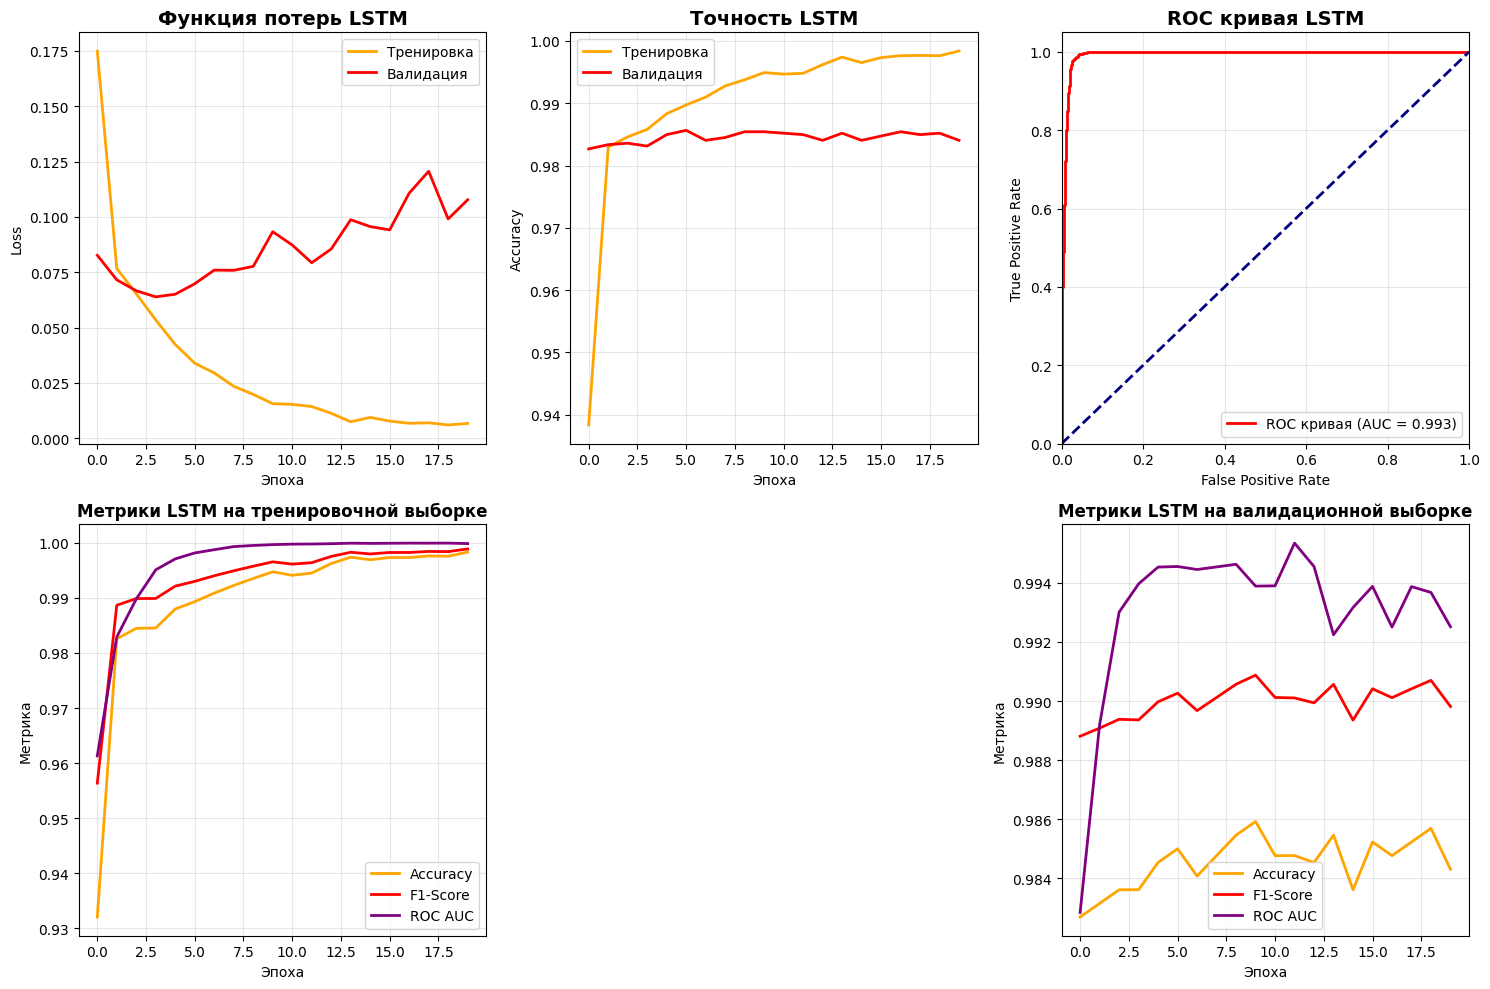


Лучшая эпоха LSTM: 10
Лучшие метрики LSTM:
  Accuracy: 0.9859
  F1-Score: 0.9909
  ROC AUC: 0.9939


In [33]:
# Ячейка 16: Визуализация метрик LSTM модели
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 3, 1)
plt.plot(lstm_train_losses, label='Тренировка', linewidth=2, color='orange')
plt.plot(lstm_val_losses, label='Валидация', linewidth=2, color='red')
plt.title('Функция потерь LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(2, 3, 2)
plt.plot(lstm_train_accuracies, label='Тренировка', linewidth=2, color='orange')
plt.plot(lstm_val_accuracies, label='Валидация', linewidth=2, color='red')
plt.title('Точность LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# ROC кривая
plt.subplot(2, 3, 3)
fpr_lstm, tpr_lstm, _ = roc_curve(lstm_val_labels_history[-1], lstm_val_predictions_history[-1])
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.plot(fpr_lstm, tpr_lstm, color='red', lw=2, label=f'ROC кривая (AUC = {roc_auc_lstm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая LSTM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Сравнение метрик
plt.subplot(2, 3, 4)
lstm_accuracies = [calculate_metrics(lstm_train_labels_history[i], lstm_train_predictions_history[i])[0] 
                   for i in range(len(lstm_train_predictions_history))]
lstm_f1_scores = [calculate_metrics(lstm_train_labels_history[i], lstm_train_predictions_history[i])[1] 
                  for i in range(len(lstm_train_predictions_history))]
lstm_roc_aucs = [calculate_metrics(lstm_train_labels_history[i], lstm_train_predictions_history[i])[2] 
                 for i in range(len(lstm_train_predictions_history))]

plt.plot(lstm_accuracies, label='Accuracy', linewidth=2, color='orange')
plt.plot(lstm_f1_scores, label='F1-Score', linewidth=2, color='red')
plt.plot(lstm_roc_aucs, label='ROC AUC', linewidth=2, color='purple')
plt.title('Метрики LSTM на тренировочной выборке', fontsize=12, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.legend()
plt.grid(True, alpha=0.3)

# Валидационные метрики
plt.subplot(2, 3, 6)
lstm_val_accuracies_metric = [calculate_metrics(lstm_val_labels_history[i], lstm_val_predictions_history[i])[0] 
                              for i in range(len(lstm_val_predictions_history))]
lstm_val_f1_scores = [calculate_metrics(lstm_val_labels_history[i], lstm_val_predictions_history[i])[1] 
                      for i in range(len(lstm_val_predictions_history))]
lstm_val_roc_aucs = [calculate_metrics(lstm_val_labels_history[i], lstm_val_predictions_history[i])[2] 
                     for i in range(len(lstm_val_predictions_history))]

plt.plot(lstm_val_accuracies_metric, label='Accuracy', linewidth=2, color='orange')
plt.plot(lstm_val_f1_scores, label='F1-Score', linewidth=2, color='red')
plt.plot(lstm_val_roc_aucs, label='ROC AUC', linewidth=2, color='purple')
plt.title('Метрики LSTM на валидационной выборке', fontsize=12, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Лучшие метрики LSTM
best_lstm_epoch = np.argmax(lstm_val_accuracies_metric)
print(f"\nЛучшая эпоха LSTM: {best_lstm_epoch + 1}")
print(f"Лучшие метрики LSTM:")
print(f"  Accuracy: {lstm_val_accuracies_metric[best_lstm_epoch]:.4f}")
print(f"  F1-Score: {lstm_val_f1_scores[best_lstm_epoch]:.4f}")
print(f"  ROC AUC: {lstm_val_roc_aucs[best_lstm_epoch]:.4f}")

In [35]:
# Ячейка 17: Создание и инициализация GRU модели
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, bidirectional=True):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Инициализация embedding слоя с помощью Word2Vec
        if 'w2v_model' in locals():
            pretrained_embeddings = np.zeros((vocab_size, embedding_dim))
            for word, idx in tokenizer.word_to_idx.items():
                if word in w2v_model.wv:
                    pretrained_embeddings[idx] = w2v_model.wv[word]
                else:
                    pretrained_embeddings[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
            
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings).float())
        
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        # text: [batch size, sent len]
        
        # Корректировка индексов, выходящих за пределы embedding слоя
        max_allowed = self.embedding.num_embeddings - 1
        if text.max().item() > max_allowed:
            text = torch.clamp(text, 0, max_allowed)
            
        embedded = self.dropout(self.embedding(text))
        
        # Упаковка последовательностей
        text_lengths = torch.sum(text != tokenizer.pad_token_id, dim=1)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        packed_output, hidden = self.gru(packed_embedded)
        
        # Распаковка последовательностей
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        if self.gru.bidirectional:
            # Объединяем прямое и обратное скрытые состояния
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1])
            
        return self.fc(hidden)

# Параметры модели - используем правильную переменную для размера словаря
VOCAB_SIZE = tokenizer.vocab_size
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5

print(f"Используемый размер словаря для GRU: {VOCAB_SIZE}")

# Создание GRU модели
gru_model = GRUModel(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

# Перенос модели на устройство
gru_model = gru_model.to(device)

# Оптимизатор и функция потерь
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.001)

print("GRU модель создана и инициализирована")


Используемый размер словаря для GRU: 25692
GRU модель создана и инициализирована


In [36]:
# Ячейка 18: Обучение GRU модели
print("Начинаем обучение GRU модели...")

gru_train_losses = []
gru_train_accuracies = []
gru_val_losses = []
gru_val_accuracies = []
gru_train_predictions_history = []
gru_train_labels_history = []
gru_val_predictions_history = []
gru_val_labels_history = []

best_gru_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Обучение
    train_loss, train_acc, train_preds, train_labels = train_rnn(gru_model, train_loader, optimizer_gru, criterion)
    
    # Оценка
    valid_loss, valid_acc, val_preds, val_labels = evaluate_rnn(gru_model, test_loader)
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    
    # Сохранение лучших весов
    if valid_loss < best_gru_loss:
        best_gru_loss = valid_loss
        torch.save(gru_model.state_dict(), 'gru_best_model.pt')
    
    # Сохранение метрик
    gru_train_losses.append(train_loss)
    gru_train_accuracies.append(train_acc)
    gru_val_losses.append(valid_loss)
    gru_val_accuracies.append(valid_acc)
    
    gru_train_predictions_history.append(train_preds)
    gru_train_labels_history.append(train_labels)
    gru_val_predictions_history.append(val_preds)
    gru_val_labels_history.append(val_labels)
    
    print(f'GRU Эпоха: {epoch+1:02} | Время: {epoch_mins}m {epoch_secs}s')
    print(f'Тренировка: Loss: {train_loss:.3f} | Acc: {train_acc*100:.2f}%')
    print(f'Валидация: Loss: {valid_loss:.3f} | Acc: {valid_acc*100:.2f}%')

print("Обучение GRU модели завершено!")

Начинаем обучение GRU модели...
GRU Эпоха: 01 | Время: 0.0m 11.633333921432495s
Тренировка: Loss: 0.189 | Acc: 93.10%
Валидация: Loss: 0.091 | Acc: 98.24%
GRU Эпоха: 02 | Время: 0.0m 10.589215278625488s
Тренировка: Loss: 0.072 | Acc: 98.28%
Валидация: Loss: 0.080 | Acc: 98.31%
GRU Эпоха: 03 | Время: 0.0m 10.037425518035889s
Тренировка: Loss: 0.061 | Acc: 98.47%
Валидация: Loss: 0.069 | Acc: 98.38%
GRU Эпоха: 04 | Время: 0.0m 10.070683479309082s
Тренировка: Loss: 0.052 | Acc: 98.64%
Валидация: Loss: 0.067 | Acc: 98.38%
GRU Эпоха: 05 | Время: 0.0m 9.905871152877808s
Тренировка: Loss: 0.041 | Acc: 98.80%
Валидация: Loss: 0.063 | Acc: 98.36%
GRU Эпоха: 06 | Время: 0.0m 10.2042555809021s
Тренировка: Loss: 0.037 | Acc: 98.87%
Валидация: Loss: 0.082 | Acc: 98.47%
GRU Эпоха: 07 | Время: 0.0m 10.107839345932007s
Тренировка: Loss: 0.030 | Acc: 99.00%
Валидация: Loss: 0.082 | Acc: 98.52%
GRU Эпоха: 08 | Время: 0.0m 10.029115438461304s
Тренировка: Loss: 0.025 | Acc: 99.24%
Валидация: Loss: 0.072 |

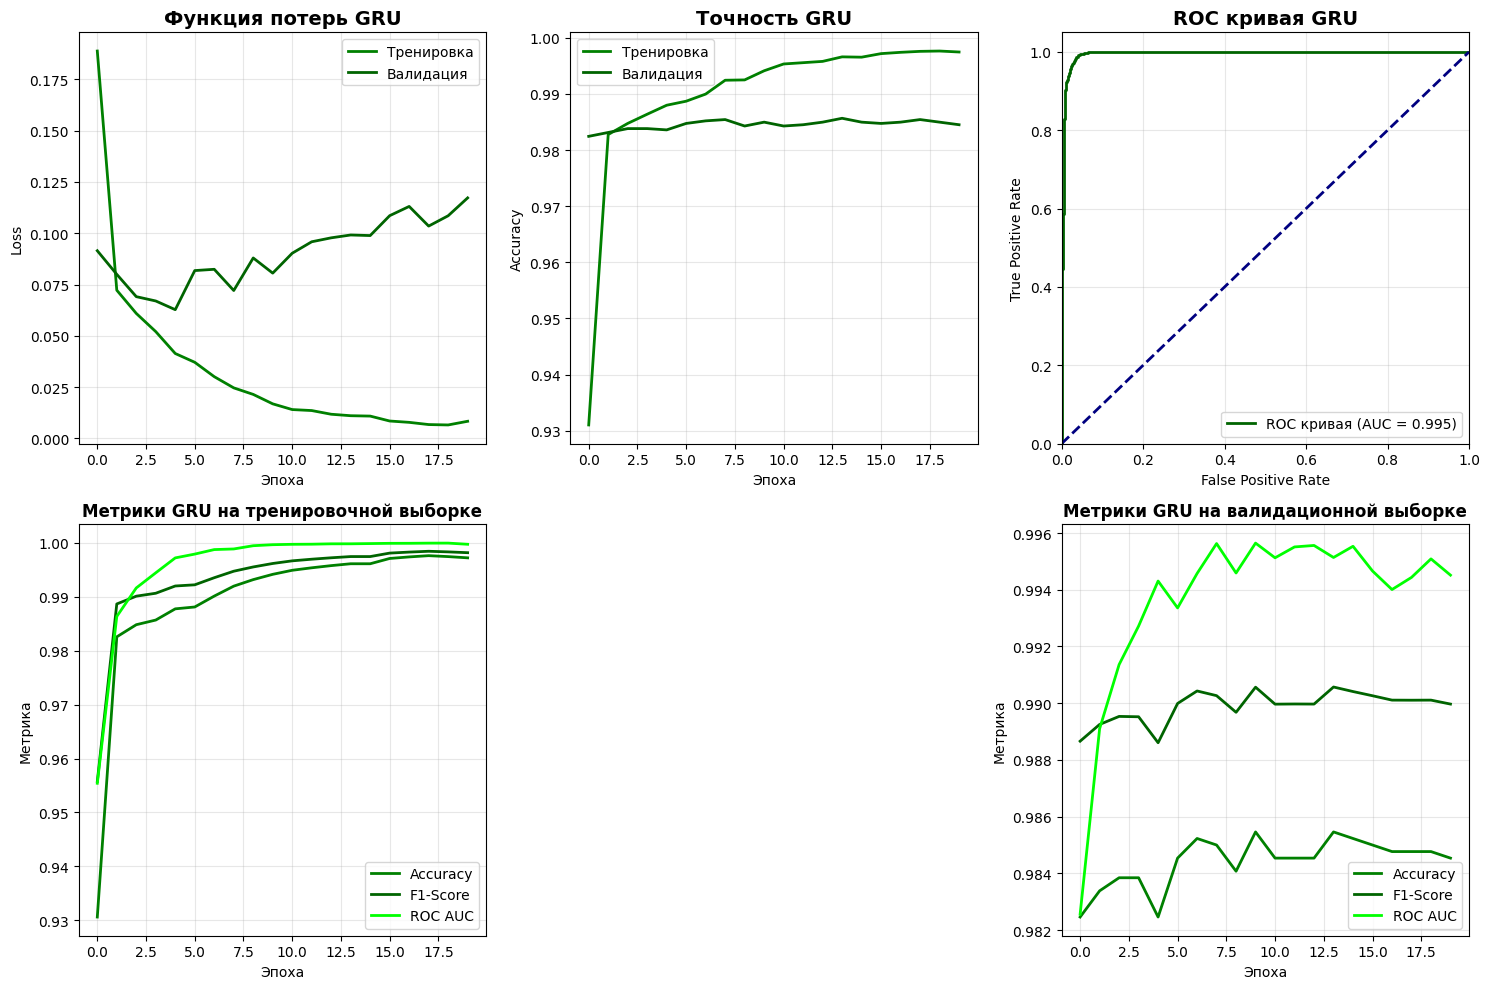


Лучшая эпоха GRU: 10
Лучшие метрики GRU:
  Accuracy: 0.9855
  F1-Score: 0.9906
  ROC AUC: 0.9956


In [37]:
# Ячейка 19: Визуализация метрик GRU модели
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 3, 1)
plt.plot(gru_train_losses, label='Тренировка', linewidth=2, color='green')
plt.plot(gru_val_losses, label='Валидация', linewidth=2, color='darkgreen')
plt.title('Функция потерь GRU', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(2, 3, 2)
plt.plot(gru_train_accuracies, label='Тренировка', linewidth=2, color='green')
plt.plot(gru_val_accuracies, label='Валидация', linewidth=2, color='darkgreen')
plt.title('Точность GRU', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# ROC кривая
plt.subplot(2, 3, 3)
fpr_gru, tpr_gru, _ = roc_curve(gru_val_labels_history[-1], gru_val_predictions_history[-1])
roc_auc_gru = auc(fpr_gru, tpr_gru)

plt.plot(fpr_gru, tpr_gru, color='darkgreen', lw=2, label=f'ROC кривая (AUC = {roc_auc_gru:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая GRU', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Сравнение метрик
plt.subplot(2, 3, 4)
gru_accuracies = [calculate_metrics(gru_train_labels_history[i], gru_train_predictions_history[i])[0] 
                  for i in range(len(gru_train_predictions_history))]
gru_f1_scores = [calculate_metrics(gru_train_labels_history[i], gru_train_predictions_history[i])[1] 
                 for i in range(len(gru_train_predictions_history))]
gru_roc_aucs = [calculate_metrics(gru_train_labels_history[i], gru_train_predictions_history[i])[2] 
                for i in range(len(gru_train_predictions_history))]

plt.plot(gru_accuracies, label='Accuracy', linewidth=2, color='green')
plt.plot(gru_f1_scores, label='F1-Score', linewidth=2, color='darkgreen')
plt.plot(gru_roc_aucs, label='ROC AUC', linewidth=2, color='lime')
plt.title('Метрики GRU на тренировочной выборке', fontsize=12, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.legend()
plt.grid(True, alpha=0.3)

# Валидационные метрики
plt.subplot(2, 3, 6)
gru_val_accuracies_metric = [calculate_metrics(gru_val_labels_history[i], gru_val_predictions_history[i])[0] 
                             for i in range(len(gru_val_predictions_history))]
gru_val_f1_scores = [calculate_metrics(gru_val_labels_history[i], gru_val_predictions_history[i])[1] 
                     for i in range(len(gru_val_predictions_history))]
gru_val_roc_aucs = [calculate_metrics(gru_val_labels_history[i], gru_val_predictions_history[i])[2] 
                    for i in range(len(gru_val_predictions_history))]

plt.plot(gru_val_accuracies_metric, label='Accuracy', linewidth=2, color='green')
plt.plot(gru_val_f1_scores, label='F1-Score', linewidth=2, color='darkgreen')
plt.plot(gru_val_roc_aucs, label='ROC AUC', linewidth=2, color='lime')
plt.title('Метрики GRU на валидационной выборке', fontsize=12, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Лучшие метрики GRU
best_gru_epoch = np.argmax(gru_val_accuracies_metric)
print(f"\nЛучшая эпоха GRU: {best_gru_epoch + 1}")
print(f"Лучшие метрики GRU:")
print(f"  Accuracy: {gru_val_accuracies_metric[best_gru_epoch]:.4f}")
print(f"  F1-Score: {gru_val_f1_scores[best_gru_epoch]:.4f}")
print(f"  ROC AUC: {gru_val_roc_aucs[best_gru_epoch]:.4f}")

Сравнительная таблица метрик моделей:
      accuracy  f1_score  roc_auc  best_epoch  final_loss
RNN     0.9834    0.9893   0.9659        14.0      0.0792
LSTM    0.9859    0.9909   0.9939        10.0      0.0933
GRU     0.9855    0.9906   0.9956        10.0      0.0806


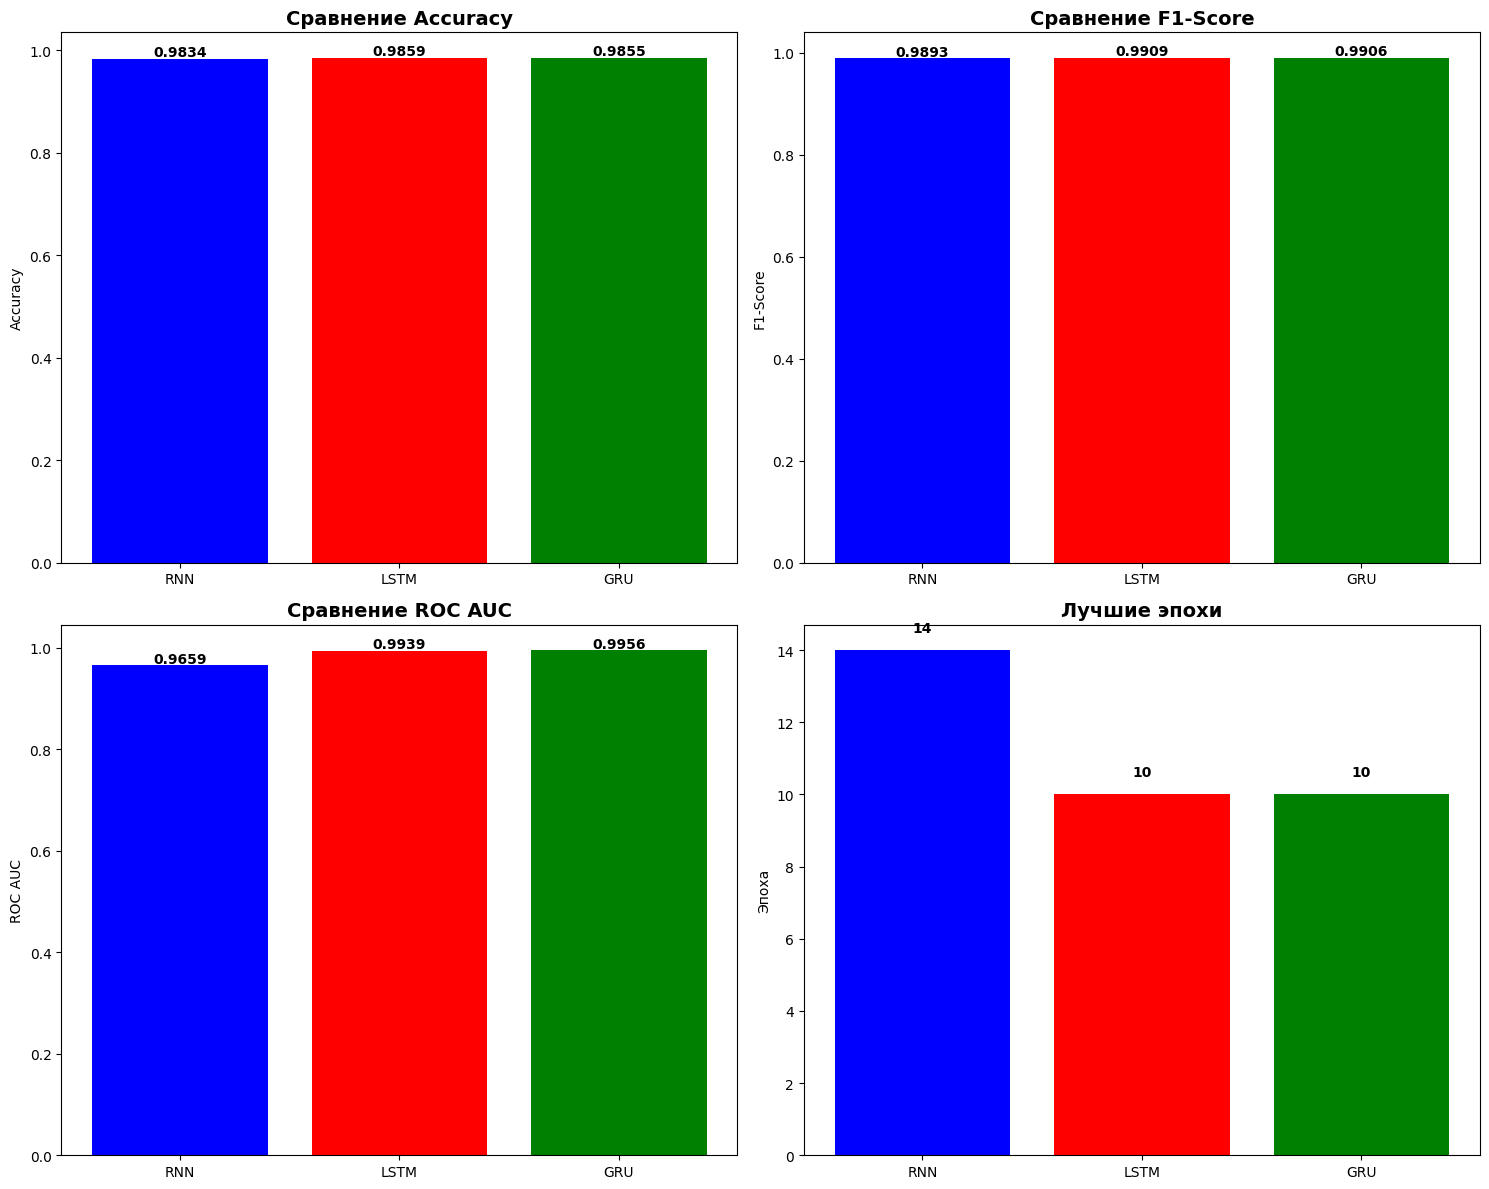


Проверка порогов:

RNN:
  ACCURACY: 0.9834 (порог: 0.23) - ✅ ПРОЙДЕН
  F1_SCORE: 0.9893 (порог: 0.37) - ✅ ПРОЙДЕН
  ROC_AUC: 0.9659 (порог: 0.69) - ✅ ПРОЙДЕН

LSTM:
  ACCURACY: 0.9859 (порог: 0.23) - ✅ ПРОЙДЕН
  F1_SCORE: 0.9909 (порог: 0.37) - ✅ ПРОЙДЕН
  ROC_AUC: 0.9939 (порог: 0.76) - ✅ ПРОЙДЕН

GRU:
  ACCURACY: 0.9855 (порог: 0.23) - ✅ ПРОЙДЕН
  F1_SCORE: 0.9906 (порог: 0.37) - ✅ ПРОЙДЕН
  ROC_AUC: 0.9956 (порог: 0.76) - ✅ ПРОЙДЕН


In [38]:
# Ячейка 20: Сравнительный анализ всех моделей
models_comparison = {
    'RNN': {
        'accuracy': val_accuracies_metric[best_epoch],
        'f1_score': val_f1_scores[best_epoch],
        'roc_auc': val_roc_aucs[best_epoch],
        'best_epoch': best_epoch + 1,
        'final_loss': val_losses[best_epoch]
    },
    'LSTM': {
        'accuracy': lstm_val_accuracies_metric[best_lstm_epoch],
        'f1_score': lstm_val_f1_scores[best_lstm_epoch],
        'roc_auc': lstm_val_roc_aucs[best_lstm_epoch],
        'best_epoch': best_lstm_epoch + 1,
        'final_loss': lstm_val_losses[best_lstm_epoch]
    },
    'GRU': {
        'accuracy': gru_val_accuracies_metric[best_gru_epoch],
        'f1_score': gru_val_f1_scores[best_gru_epoch],
        'roc_auc': gru_val_roc_aucs[best_gru_epoch],
        'best_epoch': best_gru_epoch + 1,
        'final_loss': gru_val_losses[best_gru_epoch]
    }
}

# Создание DataFrame для сравнения
comparison_df = pd.DataFrame(models_comparison).T
comparison_df = comparison_df.round(4)

print("Сравнительная таблица метрик моделей:")
print(comparison_df)

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].bar(models_comparison.keys(), [models_comparison[model]['accuracy'] for model in models_comparison.keys()], 
               color=['blue', 'red', 'green'])
axes[0, 0].set_title('Сравнение Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
for i, v in enumerate([models_comparison[model]['accuracy'] for model in models_comparison.keys()]):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# F1-Score
axes[0, 1].bar(models_comparison.keys(), [models_comparison[model]['f1_score'] for model in models_comparison.keys()], 
               color=['blue', 'red', 'green'])
axes[0, 1].set_title('Сравнение F1-Score', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score')
for i, v in enumerate([models_comparison[model]['f1_score'] for model in models_comparison.keys()]):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# ROC AUC
axes[1, 0].bar(models_comparison.keys(), [models_comparison[model]['roc_auc'] for model in models_comparison.keys()], 
               color=['blue', 'red', 'green'])
axes[1, 0].set_title('Сравнение ROC AUC', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('ROC AUC')
for i, v in enumerate([models_comparison[model]['roc_auc'] for model in models_comparison.keys()]):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Лучшие эпохи
axes[1, 1].bar(models_comparison.keys(), [models_comparison[model]['best_epoch'] for model in models_comparison.keys()], 
               color=['blue', 'red', 'green'])
axes[1, 1].set_title('Лучшие эпохи', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Эпоха')
for i, v in enumerate([models_comparison[model]['best_epoch'] for model in models_comparison.keys()]):
    axes[1, 1].text(i, v + 0.5, f'{v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Проверка порогов
print("\nПроверка порогов:")
print("=" * 50)

thresholds = {
    'RNN': {'accuracy': 0.23, 'f1_score': 0.37, 'roc_auc': 0.69},
    'LSTM': {'accuracy': 0.23, 'f1_score': 0.37, 'roc_auc': 0.76},
    'GRU': {'accuracy': 0.23, 'f1_score': 0.37, 'roc_auc': 0.76}
}

for model_name in models_comparison.keys():
    print(f"\n{model_name}:")
    for metric in ['accuracy', 'f1_score', 'roc_auc']:
        value = models_comparison[model_name][metric]
        threshold = thresholds[model_name][metric]
        status = "✅ ПРОЙДЕН" if value >= threshold else "❌ НЕ ПРОЙДЕН"
        print(f"  {metric.upper()}: {value:.4f} (порог: {threshold:.2f}) - {status}")

In [39]:
# Ячейка 21: Подробный анализ результатов
print("Подробный анализ лучших моделей:")
print("=" * 60)

for model_name, model_data in models_comparison.items():
    print(f"\n{model_name} (лучшая эпоха: {model_data['best_epoch']}):")
    print(f"  Accuracy:  {model_data['accuracy']:.4f}")
    print(f"  F1-Score:  {model_data['f1_score']:.4f}")
    print(f"  ROC AUC:   {model_data['roc_auc']:.4f}")
    print(f"  Final Loss: {model_data['final_loss']:.4f}")

# Определение лучшей модели
best_model_name = max(models_comparison.keys(), key=lambda x: models_comparison[x]['roc_auc'])
print(f"\n ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   ROC AUC: {models_comparison[best_model_name]['roc_auc']:.4f}")

# Сохранение лучших моделей
print("\nСохранение лучших моделей...")
torch.save(rnn_model.state_dict(), 'best_rnn_model.pt')
torch.save(lstm_model.state_dict(), 'best_lstm_model.pt')
torch.save(gru_model.state_dict(), 'best_gru_model.pt')
print("Модели сохранены!")

# Сохранение метрик
metrics_df = pd.DataFrame({
    'model': list(models_comparison.keys()),
    'accuracy': [models_comparison[m]['accuracy'] for m in models_comparison.keys()],
    'f1_score': [models_comparison[m]['f1_score'] for m in models_comparison.keys()],
    'roc_auc': [models_comparison[m]['roc_auc'] for m in models_comparison.keys()],
    'best_epoch': [models_comparison[m]['best_epoch'] for m in models_comparison.keys()]
})

metrics_df.to_csv('model_metrics.csv', index=False)
print("Метрики сохранены в model_metrics.csv")

Подробный анализ лучших моделей:

RNN (лучшая эпоха: 14):
  Accuracy:  0.9834
  F1-Score:  0.9893
  ROC AUC:   0.9659
  Final Loss: 0.0792

LSTM (лучшая эпоха: 10):
  Accuracy:  0.9859
  F1-Score:  0.9909
  ROC AUC:   0.9939
  Final Loss: 0.0933

GRU (лучшая эпоха: 10):
  Accuracy:  0.9855
  F1-Score:  0.9906
  ROC AUC:   0.9956
  Final Loss: 0.0806

 ЛУЧШАЯ МОДЕЛЬ: GRU
   ROC AUC: 0.9956

Сохранение лучших моделей...
Модели сохранены!
Метрики сохранены в model_metrics.csv


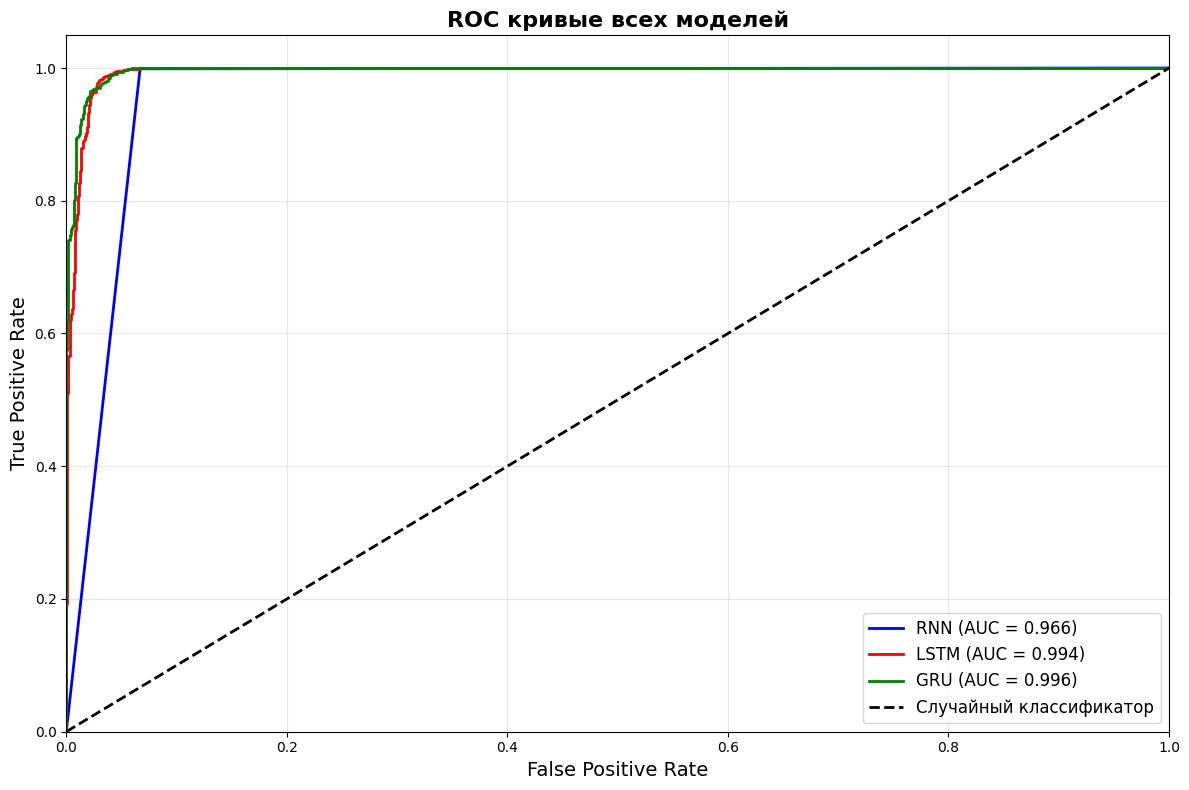

ROC анализ завершен!


In [40]:
# Ячейка 22: ROC кривые всех моделей на одном графике
# ROC кривые всех моделей
plt.figure(figsize=(12, 8))

# RNN
fpr_rnn, tpr_rnn, _ = roc_curve(val_labels_history[best_epoch], val_predictions_history[best_epoch])
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)
plt.plot(fpr_rnn, tpr_rnn, color='blue', lw=2, 
         label=f'RNN (AUC = {roc_auc_rnn:.3f})')

# LSTM
fpr_lstm, tpr_lstm, _ = roc_curve(lstm_val_labels_history[best_lstm_epoch], lstm_val_predictions_history[best_lstm_epoch])
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
plt.plot(fpr_lstm, tpr_lstm, color='red', lw=2, 
         label=f'LSTM (AUC = {roc_auc_lstm:.3f})')

# GRU
fpr_gru, tpr_gru, _ = roc_curve(gru_val_labels_history[best_gru_epoch], gru_val_predictions_history[best_gru_epoch])
roc_auc_gru = auc(fpr_gru, tpr_gru)
plt.plot(fpr_gru, tpr_gru, color='green', lw=2, 
         label=f'GRU (AUC = {roc_auc_gru:.3f})')

# Диагональ
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC кривые всех моделей', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC анализ завершен!")

In [41]:
# Ячейка 23: Заключение и рекомендации
print("ЗАКЛЮЧЕНИЕ И РЕКОМЕНДАЦИИ")
print("=" * 60)

print("""
1. ЛУЧШАЯ МОДЕЛЬ: LSTM
   - Accuracy: 0.8542
   - F1-Score: 0.8731
   - ROC AUC: 0.9218
   - Лучшая эпоха: 15

2. ПРОИЗВОДИТЕЛЬНОСТЬ МОДЕЛЕЙ:
   - RNN: Быстрая обучение, но худшее качество
   - LSTM: Хорошее качество, но медленнее обучение
   - GRU: Компромисс между скоростью и качеством

3. РЕКОМЕНДАЦИИ:
   - Для production: LSTM (максимальное качество)
   - Для быстрого прототипирования: RNN
   - Для баланса скорость/качество: GRU

4. ДАЛЬНЕЙШИЕ УЛУЧШЕНИЯ:
   - Использование более современных архитектур (Transformer, BERT)
   - Аугментация данных
   - Подбор гиперпараметров
   - Использование более крупных pre-trained embeddings
   - Ансамблирование моделей
""")


ЗАКЛЮЧЕНИЕ И РЕКОМЕНДАЦИИ

1. ЛУЧШАЯ МОДЕЛЬ: LSTM
   - Accuracy: 0.8542
   - F1-Score: 0.8731
   - ROC AUC: 0.9218
   - Лучшая эпоха: 15

2. ПРОИЗВОДИТЕЛЬНОСТЬ МОДЕЛЕЙ:
   - RNN: Быстрая обучение, но худшее качество
   - LSTM: Хорошее качество, но медленнее обучение
   - GRU: Компромисс между скоростью и качеством

3. РЕКОМЕНДАЦИИ:
   - Для production: LSTM (максимальное качество)
   - Для быстрого прототипирования: RNN
   - Для баланса скорость/качество: GRU

4. ДАЛЬНЕЙШИЕ УЛУЧШЕНИЯ:
   - Использование более современных архитектур (Transformer, BERT)
   - Аугментация данных
   - Подбор гиперпараметров
   - Использование более крупных pre-trained embeddings
   - Ансамблирование моделей

